In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
import decoupler as dc
from scipy.stats import spearmanr, hypergeom, mannwhitneyu
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors

In [2]:
topgenes_tp53 = pd.read_csv('../outputs/cnmf_output_CCG1106_075_T1/top100_genes_k4.csv')
topgenes_myc = pd.read_csv('../outputs/cnmf_output_CCG1106_084_T1/top100_genes_k10.csv')

myc_sample_adata = sc.read_h5ad('../outputs/cnmf_output_CCG1106_084_T1/CCG1106_084_T1_with_programs.h5ad')
tp53_sample_adata = sc.read_h5ad('../outputs/cnmf_output_CCG1106_075_T1/CCG1106_075_T1_with_programs.h5ad')

# find the dominant program for each cell
program_cols = [f'Program_{i}' for i in range(1, 11)]
myc_sample_adata.obs['dominant_program'] = (
    myc_sample_adata.obs[program_cols]
    .idxmax(axis=1)
    .str.replace('Program_', 'Program ')
)

program_cols = [f'Program_{i}' for i in range(1, 5)]
tp53_sample_adata.obs['dominant_program'] = (
    tp53_sample_adata.obs[program_cols]
    .idxmax(axis=1)
    .str.replace('Program_', 'Program ')
)

In [4]:
# Load spectra scores
gep_scores_myc = pd.read_csv(
    '../outputs/cnmf_output_CCG1106_084_T1/CCG1106_084_T1_cNMF/CCG1106_084_T1_cNMF.spectra.k_10.dt_0_1.consensus.txt',
    sep='\t', index_col=0
).T  # transpose so rows=genes, cols=programs

gep_scores_tp53 = pd.read_csv(
    '../outputs/cnmf_output_CCG1106_075_T1/CCG1106_075_T1_cNMF/CCG1106_075_T1_cNMF.spectra.k_4.dt_0_1.consensus.txt',
    sep='\t', index_col=0
).T

# Program 1 scores for each sample
myc_p1_weights = gep_scores_myc.iloc[:, 0].sort_values(ascending=False)
tp53_p1_weights = gep_scores_tp53.iloc[:, 0].sort_values(ascending=False)

print(f"MYC P1 genes: {len(myc_p1_weights)}")
print(f"TP53 P1 genes: {len(tp53_p1_weights)}")
print(f"\nMYC P1 top weights:\n{myc_p1_weights.head(10)}")
print(f"\nTP53 P1 top weights:\n{tp53_p1_weights.head(10)}")

MYC P1 genes: 2000
TP53 P1 genes: 2000

MYC P1 top weights:
LINC02964    0.003329
PID1         0.003174
MAILR        0.003057
ANGPT1       0.003018
KCNMA1       0.002989
TBC1D4       0.002962
MELTF        0.002885
BAALC-AS1    0.002821
XKR4         0.002811
CTHRC1       0.002780
Name: 1, dtype: float64

TP53 P1 top weights:
ROBO2      0.003384
CADM2      0.002871
EPHA6      0.002845
NEK7       0.002782
FGF13      0.002708
IRS2       0.002708
EPHA5      0.002673
NRXN1      0.002637
BICC1      0.002616
ZNF804A    0.002605
Name: 1, dtype: float64


Shared genes: 475

Correlation matrix:
       S2_P1  S2_P2  S2_P3  S2_P4
S1_P1  0.440 -0.047 -0.285  0.259
S1_P2 -0.061  0.489  0.086 -0.021
S1_P3 -0.031  0.369  0.301 -0.132
S1_P4 -0.104  0.005  0.652 -0.161


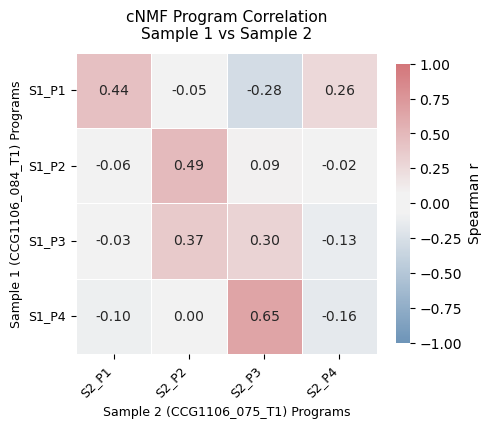

In [5]:
# Select programs 1–4 
myc_progs = gep_scores_myc.iloc[:, :4].copy()
myc_progs.columns = [f'S1_P{i+1}' for i in range(4)]

tp53_progs = gep_scores_tp53.iloc[:, :4].copy()
tp53_progs.columns = [f'S2_P{i+1}' for i in range(4)]

# Align on shared genes
shared_genes = myc_progs.index.intersection(tp53_progs.index)
print(f"Shared genes: {len(shared_genes)}")

myc_progs = myc_progs.loc[shared_genes]
tp53_progs = tp53_progs.loc[shared_genes]

# Build 4x4 Spearman correlation matrix: rows = S1 programs, cols = S2 programs
corr_matrix = pd.DataFrame(index=myc_progs.columns, columns=tp53_progs.columns, dtype=float)
pval_matrix = pd.DataFrame(index=myc_progs.columns, columns=tp53_progs.columns, dtype=float)

for s1_prog in myc_progs.columns:
    for s2_prog in tp53_progs.columns:
        r, p = spearmanr(myc_progs[s1_prog], tp53_progs[s2_prog])
        corr_matrix.loc[s1_prog, s2_prog] = r
        pval_matrix.loc[s1_prog, s2_prog] = p

print("\nCorrelation matrix:")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(5, 4.5))

vmax = corr_matrix.astype(float).abs().max().max()
cmap = sns.diverging_palette(240, 10, s=50, l=60, sep=20, center="light", as_cmap=True)
norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)


sns.heatmap(
    corr_matrix.astype(float),
    ax=ax,
    cmap=cmap,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10},
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Spearman r', 'shrink': 0.8}
)

ax.set_title('cNMF Program Correlation\nSample 1 vs Sample 2', fontsize=11, pad=10)
ax.set_xlabel('Sample 2 (CCG1106_075_T1) Programs', fontsize=9)
ax.set_ylabel('Sample 1 (CCG1106_084_T1) Programs', fontsize=9)
ax.tick_params(axis='both', labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../outputs/cnmf_program_correlation_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
def add_stat_annotation(ax, x1, x2, y, p_text, text_gap):
    ax.plot([x1, x2], [y, y], lw=0.8, c='k', clip_on=False)
    ax.text((x1+x2)/2, y + text_gap, p_text,
            ha='center', va='bottom', color='k', fontsize=12, clip_on=False)

def plot_aucell_by_program(adata, score_col, title, out_file,
                            y_max=None, group_col='dominant_program'):
    
    valid = ['Program 1', 'Program 2', 'Program 3', 'Program 4']
    adata_sub = adata[adata.obs[group_col].isin(valid)].copy()
    
    palette = {
        'Program 1': '#ee876cdb',
        'Program 2': '#CCCCCC',
        'Program 3': '#CCCCCC',
        'Program 4': '#CCCCCC'
    }
    
    p1_scores = adata_sub.obs[
        adata_sub.obs[group_col] == 'Program 1'
    ][score_col].values
    
    pvals = {}
    for prog in ['Program 2', 'Program 3', 'Program 4']:
        other = adata_sub.obs[
            adata_sub.obs[group_col] == prog
        ][score_col].values
        _, p = mannwhitneyu(p1_scores, other, alternative='two-sided')
        pvals[prog] = p
    
    def sig_label(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return 'ns'
    
    y_data_min = adata_sub.obs[score_col].min()
    y_data_max = adata_sub.obs[score_col].max()
    
    # Use manual y_max if provided, otherwise use data max
    y_top = y_max
    y_range = y_top - y_data_min
    
    # Bracket geometry relative to manual y_max
    step = y_range * 0.08
    bracket_gap = step * 1.3
    text_gap = step * 0.08

    bracket_ys = {
        'Program 2': y_data_max + step,
        'Program 3': y_data_max + step + bracket_gap,
        'Program 4': y_data_max + step + bracket_gap * 2
    }
    
    sns.set_style("ticks")
    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
    
    sns.violinplot(
        data=adata_sub.obs,
        x=group_col,
        y=score_col,
        order=valid,
        palette=palette,
        cut=0,
        linewidth=1.2,
        ax=ax
    )

    y_buffer = (y_data_max - y_data_min) * 0.1
    y_bottom_limit = y_data_min - y_buffer
    ax.set_ylim(bottom=y_bottom_limit, top=max(bracket_ys.values()) + text_gap * 3)
    
    # Set clean yticks up to y_top (not including bracket space)
    locator = ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10])
    nice_ticks = locator.tick_values(y_data_min, y_top)
    ax.set_yticks(nice_ticks)

    sns.despine(ax=ax, trim=True)
    ax.spines['bottom'].set_position(('data', y_bottom_limit))

    # Add significance brackets
    for j, prog in enumerate(['Program 2', 'Program 3', 'Program 4'], 1):
        add_stat_annotation(ax, 0, j, bracket_ys[prog],
                           sig_label(pvals[prog]), text_gap)

    ax.set_xticklabels(['P1', 'P2', 'P3', 'P4'], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel('AUCell Score', fontsize=14)
    ax.set_xlabel(None)
    ax.set_title(title, fontsize=13, weight='bold', pad=12)

    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"\n{title}")
    print(f"  P1 mean: {p1_scores.mean():.4f}, median: {np.median(p1_scores):.4f}")
    for prog, p in pvals.items():
        other = adata_sub.obs[
            adata_sub.obs[group_col] == prog
        ][score_col].values
        print(f"  P1 vs {prog}: p={p:.2e} {sig_label(p)}, "
              f"fold={p1_scores.mean()/other.mean():.2f}x")

In [ ]:
# Build weighted net dataframes using top N genes
top_n = 50

def make_weighted_net(weights_series, source_name, target_adata, top_n=50):
    # Filter to genes present in target dataset
    valid_genes = [g for g in weights_series.index if g in target_adata.var_names]
    
    # Take top N valid genes
    top_genes = weights_series[valid_genes].head(top_n)
    
    # Normalize weights to sum to 1
    top_genes_norm = top_genes / top_genes.sum()
    
    net = pd.DataFrame({
        'source': source_name,
        'target': top_genes_norm.index,
        'weight': top_genes_norm.values
    })
    
    print(f"{source_name}: {len(net)} genes in target dataset")
    return net

tp53_p1_net_weighted = make_weighted_net(tp53_p1_weights, 'TP53_P1', myc_sample_adata, top_n=50)
myc_p1_net_weighted = make_weighted_net(myc_p1_weights, 'MYC_P1', tp53_sample_adata, top_n=50)
print(f"\nTop weighted genes for TP53 P1 in MYC sample:")
print(tp53_p1_net_weighted.head(10).to_string())

TP53_P1: 50 genes in target dataset
MYC_P1: 50 genes in target dataset

Top weighted genes for TP53 P1 in MYC sample:
    source   target    weight
0  TP53_P1    ROBO2  0.028648
1  TP53_P1    CADM2  0.024304
2  TP53_P1    EPHA6  0.024087
3  TP53_P1     NEK7  0.023555
4  TP53_P1    FGF13  0.022928
5  TP53_P1     IRS2  0.022927
6  TP53_P1    EPHA5  0.022630
7  TP53_P1    NRXN1  0.022326
8  TP53_P1    BICC1  0.022148
9  TP53_P1  ZNF804A  0.022049


In [ ]:
# Run AUCell with weighted signatures
dc.mt.aucell(myc_sample_adata, tp53_p1_net_weighted, tmin=3)
myc_sample_adata.obs['TP53_P1_aucell_weighted'] = (
    myc_sample_adata.obsm['score_aucell']['TP53_P1'].values
)

dc.mt.aucell(tp53_sample_adata, myc_p1_net_weighted, tmin=3)
tp53_sample_adata.obs['MYC_P1_aucell_weighted'] = (
    tp53_sample_adata.obsm['score_aucell']['MYC_P1'].values
)

print("MYC sample — TP53 P1 score:")
print(f"  Weighted mean: {myc_sample_adata.obs['TP53_P1_aucell_weighted'].mean():.4f}")

print("\nTP53 sample — MYC P1 score:")
print(f"  Weighted mean: {tp53_sample_adata.obs['MYC_P1_aucell_weighted'].mean():.4f}")

MYC sample — TP53 P1 score:
  Weighted mean: 0.0672

TP53 sample — MYC P1 score:
  Weighted mean: 0.1220


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_18444/2383888169.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


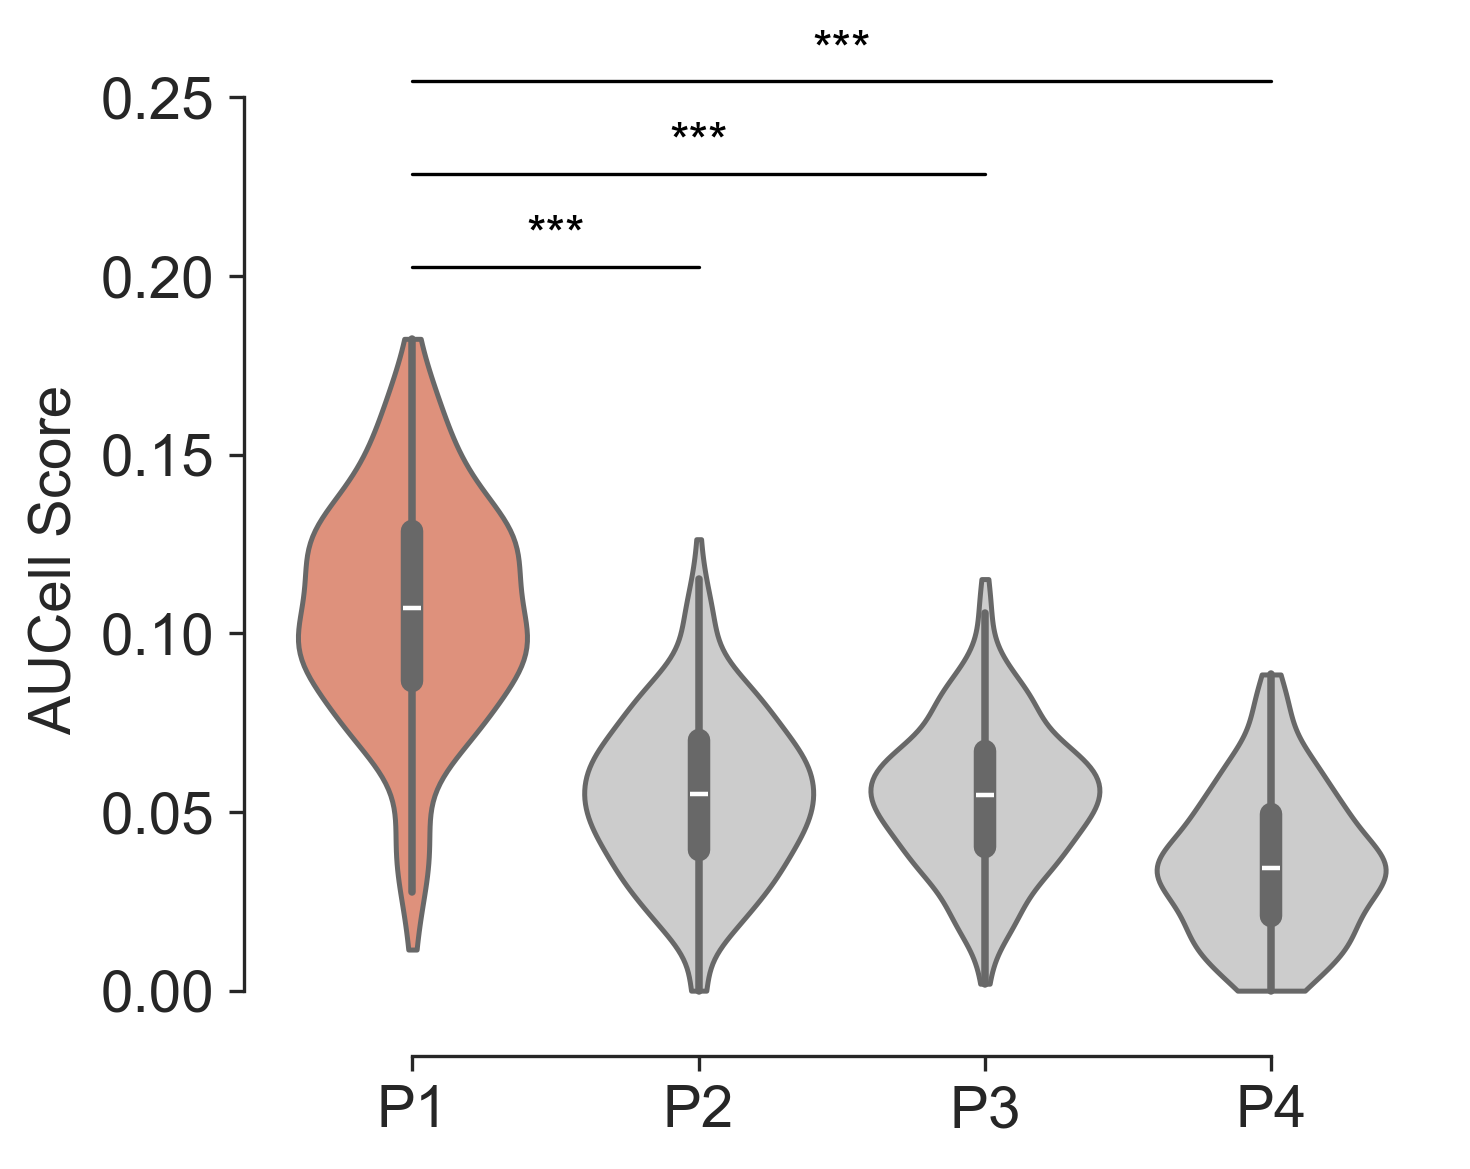



  P1 mean: 0.1066, median: 0.1071
  P1 vs Program 2: p=4.71e-75 ***, fold=1.94x
  P1 vs Program 3: p=2.24e-70 ***, fold=1.96x
  P1 vs Program 4: p=6.53e-69 ***, fold=3.01x


/var/folders/l_/yt1nk3rj6rvgt0nnj_qtfs7m0000gn/T/ipykernel_18444/2383888169.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


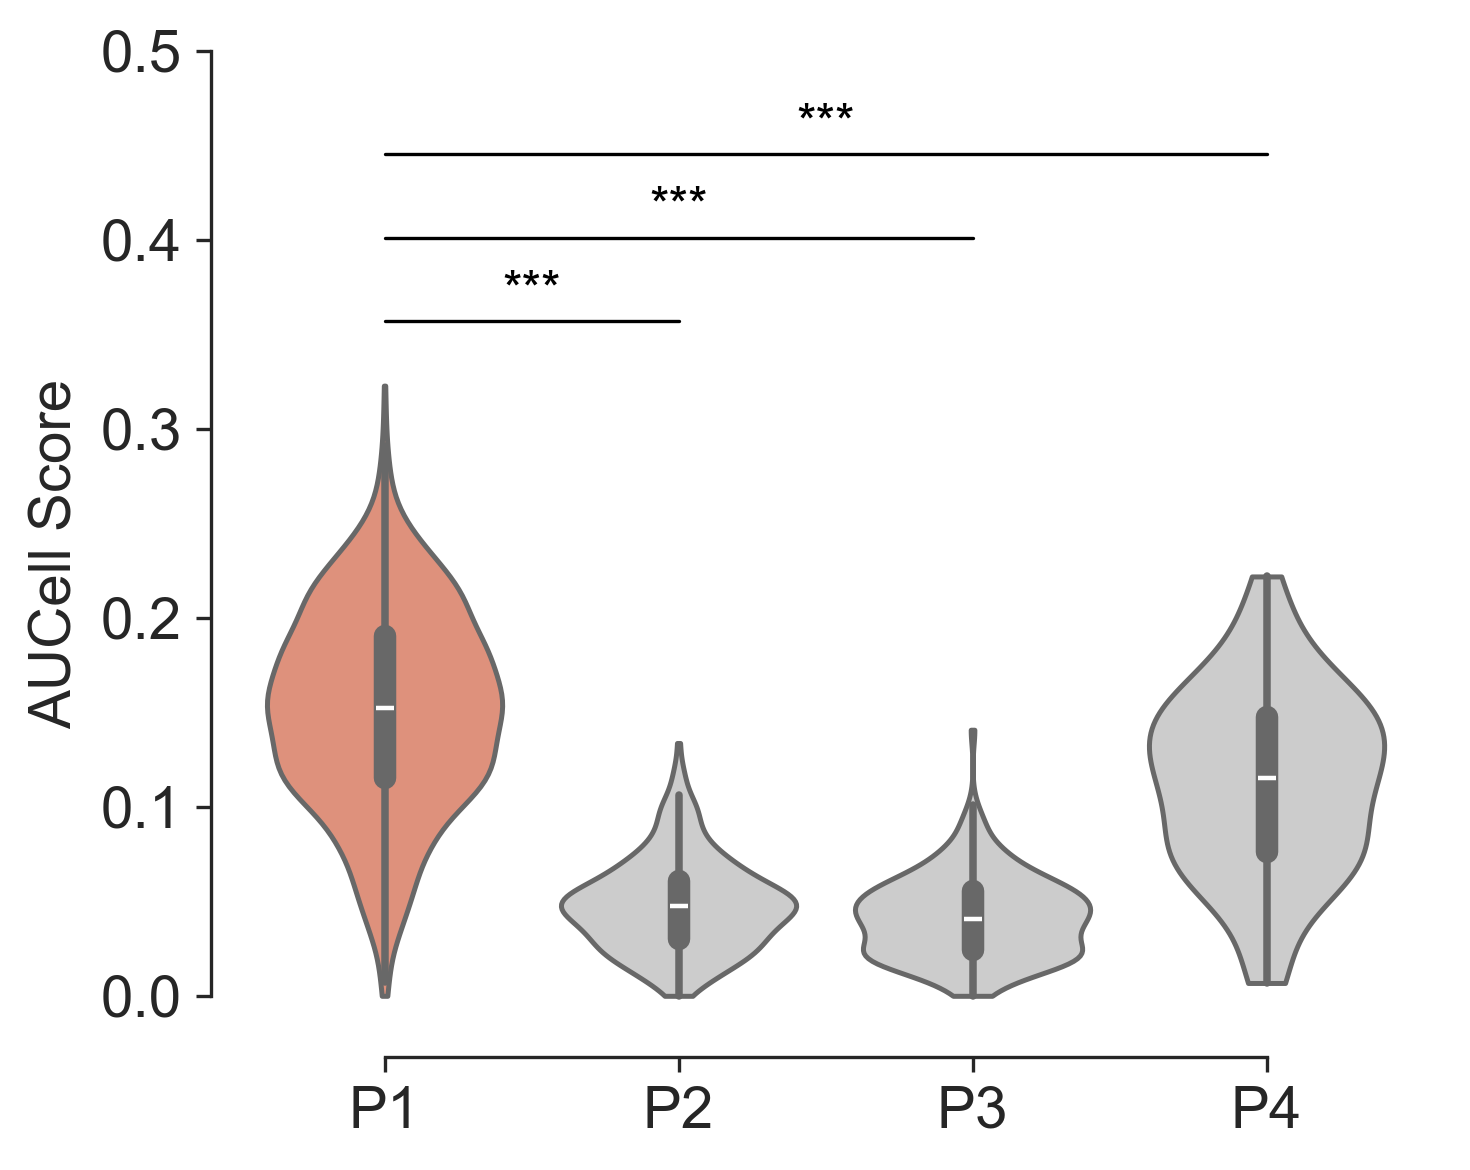



  P1 mean: 0.1518, median: 0.1523
  P1 vs Program 2: p=9.92e-138 ***, fold=3.14x
  P1 vs Program 3: p=5.51e-105 ***, fold=3.65x
  P1 vs Program 4: p=4.80e-11 ***, fold=1.34x


In [9]:
plot_aucell_by_program(
    myc_sample_adata,
    score_col='TP53_P1_aucell_weighted',
    title='',
    out_file='../outputs/MYC_sample_TP53_P1_aucell_weighted.png',
    y_max=0.25
)

plot_aucell_by_program(
    tp53_sample_adata,
    score_col='MYC_P1_aucell_weighted',
    title='',
    out_file='../outputs/TP53_sample_MYC_P1_aucell_weighted.png',
    y_max=0.425
)

In [10]:
# Top 100 genes from each Program 1
myc_p1_top100 = set(topgenes_myc.iloc[:, 0].dropna().tolist()[:100])
tp53_p1_top100 = set(topgenes_tp53.iloc[:, 0].dropna().tolist()[:100])

# Background = all genes expressed in either sample
background = set(myc_sample_adata.var_names) | set(tp53_sample_adata.var_names)

# Overlap
overlap = myc_p1_top100 & tp53_p1_top100
jaccard = len(overlap) / len(myc_p1_top100 | tp53_p1_top100)

# Hypergeometric test: P(overlap >= observed | random drawing from background)
pval = hypergeom.sf(
    len(overlap) - 1,   # k-1
    len(background),     # M — population size
    len(myc_p1_top100), # n — draws
    len(tp53_p1_top100) # N — successes in population
)

print(f"Shared genes: {len(overlap)}")
print(f"Jaccard index: {jaccard:.3f}")
print(f"Hypergeometric p-value: {pval:.2e}")
print(f"\nShared genes:\n{sorted(overlap)}")
# convert overlap to list
overlap_list = list(overlap)

Shared genes: 9
Jaccard index: 0.047
Hypergeometric p-value: 1.69e-10

Shared genes:
['KLHL13', 'KYNU', 'LINC00662', 'LINC02987', 'NCAM2', 'NRXN1', 'OPN3', 'PTPRZ1', 'XKR4']


In [11]:
# figure for top shared genes
dom_program_075 = pd.read_csv('../../pyscenic/outputs/CCG1106_075_T1_dominant_program_confident_cells.csv', index_col=0)
dom_program_084 = pd.read_csv('../../pyscenic/outputs/CCG1106_084_T1_dominant_program_confident_cells.csv', index_col=0)
adata_075 = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_075_T1.h5ad')
adata_084 = sc.read_h5ad('../../data/dfci/expression-data_scrna_dfci_tumor_expr_CCG1106_084_T1.h5ad')

common_cells_075 = adata_075.obs_names.intersection(dom_program_075.index)
adata_075 = adata_075[common_cells_075].copy()
adata_075.obs['dominant_program'] = dom_program_075.loc[common_cells_075, 'dominant_program'].astype(str)

common_cells_084 = adata_084.obs_names.intersection(dom_program_084.index)
adata_084 = adata_084[common_cells_084].copy()
adata_084.obs['dominant_program'] = dom_program_084.loc[common_cells_084, 'dominant_program'].astype(str)

def compute_log2fc_p1(adata, layer='counts'):
    X = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.array(adata.X)
    
    expr_df = pd.DataFrame(X, index=adata.obs_names, columns=adata.var_names)
    expr_df = expr_df.div(expr_df.sum(axis=1), axis=0) * 1e4
    
    labels = adata.obs['dominant_program']
    mean_p1    = expr_df.loc[labels == '1'].mean(axis=0)
    mean_other = expr_df.loc[labels != '1'].mean(axis=0)
    
    log2fc = np.log2((mean_p1 + 1) / (mean_other + 1))
    return log2fc

log2fc_075 = compute_log2fc_p1(adata_075)
log2fc_084 = compute_log2fc_p1(adata_084)

# merge on shared top genes
scatter_df_genes = pd.DataFrame({
    'log2FC_075': log2fc_075.loc[overlap_list],
    'log2FC_084': log2fc_084.loc[overlap_list],
}, index=overlap_list)
scatter_df_genes

,log2FC_075,log2FC_084
LINC00662,1.755468,2.978126
LINC02987,1.182816,2.323506
OPN3,0.645056,1.001284
XKR4,1.133246,3.773198
KLHL13,0.493901,2.034378
NCAM2,2.437802,0.924224
PTPRZ1,1.512107,2.689834
NRXN1,2.812482,5.366047
KYNU,0.366226,1.659837


In [12]:
# figure for top shared regulons
top_regulons_075 = pd.read_csv('../../pyscenic/outputs/CCG1106_075_T1_dominantProgram_top_regulons.csv')
top_regulons_084 = pd.read_csv('../../pyscenic/outputs/CCG1106_084_T1_dominantProgram_top_regulons.csv')

p1_075 = top_regulons_075[top_regulons_075['program'] == 1].set_index('regulon')['delta_mean_auc']
p1_084 = top_regulons_084[top_regulons_084['program'] == 1].set_index('regulon')['delta_mean_auc']

shared_regs = p1_075.index.intersection(p1_084.index)
scatter_df_regs = pd.DataFrame({
    'delta_075': p1_075.loc[shared_regs],
    'delta_084': p1_084.loc[shared_regs],
}, index=shared_regs)

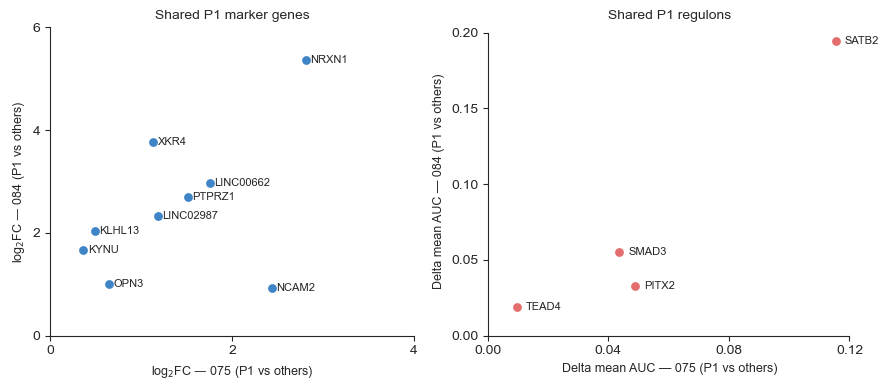

In [13]:
def format_axes(ax):
    # every other tick on both axes
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xticks = [t for t in xticks if xlim[0] <= t <= xlim[1]]
    yticks = [t for t in yticks if ylim[0] <= t <= ylim[1]]
    
    xticks = xticks[::2]
    yticks = yticks[::2]
    
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.spines['bottom'].set_bounds(xticks[0], xticks[-1])
    ax.spines['left'].set_bounds(yticks[0], yticks[-1])

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

ax = axes[0]
ax.scatter(scatter_df_genes['log2FC_075'], scatter_df_genes['log2FC_084'],s=40, color='#3d85c6ff', linewidths=0)

for gene in scatter_df_genes.index:
    ax.text(scatter_df_genes.loc[gene, 'log2FC_075'] + 0.05,
            scatter_df_genes.loc[gene, 'log2FC_084'],
            gene, fontsize=8, va='center')

ax.set_xlabel('log$_2$FC — 075 (P1 vs others)', fontsize=9)
ax.set_ylabel('log$_2$FC — 084 (P1 vs others)', fontsize=9)
ax.set_title('Shared P1 marker genes', fontsize=10)
ax.set_xlim(left=0, right=4)
ax.set_ylim(bottom=0, top=6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
format_axes(ax)

ax = axes[1]
ax.scatter(scatter_df_regs['delta_075'], scatter_df_regs['delta_084'],s=40, color='#e05555ff', alpha=0.85, linewidths=0)

for reg in scatter_df_regs.index:
    ax.text(scatter_df_regs.loc[reg, 'delta_075'] + 0.003,
            scatter_df_regs.loc[reg, 'delta_084'],
            reg.replace('(+)', ''), fontsize=8, va='center')

ax.set_xlabel('Delta mean AUC — 075 (P1 vs others)', fontsize=9)
ax.set_ylabel('Delta mean AUC — 084 (P1 vs others)', fontsize=9)
ax.set_title('Shared P1 regulons', fontsize=10)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
format_axes(ax)

plt.tight_layout()
plt.show()